# Farmer Income Prediction — LightGBM Pipeline

**Author:** Senior Data Scientist  
**Dataset:** Loan-to-Earn (LTE) Farmer Income Dataset  
**Objective:** Predict the total annual income (agricultural + non-agricultural) of Indian farmers in INR using a gradient boosting model with structured feature engineering and principled validation.

---

## Background

This dataset originates from a microfinance lending context. Each record represents a farmer identified by a unique `FarmerID`, along with features spanning:

- **Demographic and social attributes** (state, region, district, gender, marital status, ownership)
- **Credit bureau data** (number of active loans, average disbursement amount)
- **Agricultural and land features** (total land, net agricultural area, irrigation area)
- **Climate and meteorological data across 3 seasons and 3 years** (Kharif/Rabi 2020-2022)
- **Socio-economic village-level indicators** (sanitation, electricity, housing quality, road density, night light index)
- **Non-agricultural income** (direct input variable)

The prediction target is `Target_Variable/Total Income`, which satisfies the accounting identity:

$$\\text{Total Income} = \\text{Agricultural Income} + \\text{Non-Agricultural Income}$$

The key modeling insight exploited in this pipeline is that `Non_Agriculture_Income` is already available in both train and test sets, enabling a **residual modeling strategy** where the model focuses on predicting the agricultural income component. This decomposition substantially reduces model variance.

---

## Pipeline Overview

1. Library Imports and Configuration
2. Data Loading
3. Exploratory Data Analysis
4. Data Cleaning and Type Correction
5. Feature Engineering
6. Preprocessing (Encoding + Imputation)
7. Baseline Model Training with 5-Fold Cross-Validation
8. Hyperparameter Tuning
9. Final Model Training on Full Dataset
10. Model Evaluation and Residual Analysis
11. Feature Importance Analysis
12. Test Set Inference
13. Model Artifact Persistence

---

## 1. Library Imports and Configuration

All required libraries are imported here. The pipeline relies on:

- `pandas` and `numpy` for data manipulation and numerical computation
- `scipy` for statistical analysis and distribution testing
- `scikit-learn` for preprocessing, cross-validation, and evaluation metrics
- `lightgbm` as the primary gradient boosting framework
- `matplotlib` and `seaborn` for data visualization
- `joblib` for model serialization
- `warnings`, `os`, `json`, `datetime` for utility and persistence

A fixed random seed (`SEED = 42`) is set globally to ensure full reproducibility across all stochastic operations.

In [16]:
import os
import json
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy import stats
from scipy.stats import norm

from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
sns.set_palette('muted')

BASE_DIR     = r'C:\\Users\\admin\\Documents\\Portofolio\\Farmer Income Prediction'
DATASET_DIR  = os.path.join(BASE_DIR, 'Dataset')
MODEL_DIR    = os.path.join(BASE_DIR, 'Model')
ARTIFACT_DIR = os.path.join(MODEL_DIR, 'artifacts')

os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f'LightGBM version   : {lgb.__version__}')
print(f'Pandas version     : {pd.__version__}')
print(f'NumPy version      : {np.__version__}')
print(f'Artifact directory : {ARTIFACT_DIR}')

LightGBM version   : 4.7.0
Pandas version     : 3.0.5
NumPy version      : 2.5.1
Artifact directory : C:\\Users\\admin\\Documents\\Portofolio\\Farmer Income Prediction\Model\artifacts


---

## 2. Data Loading

The dataset comprises three files:

| File | Description |
|---|---|
| `lte_train.csv` | Training set (labelled), approximately 47,970 records |
| `lte_test.csv` | Test set (unlabelled), approximately 9,986 records |
| `lte_dictionary.csv` | Data dictionary defining each column |

Both train and test share identical column schemas (105 columns). The target column `Target_Variable/Total Income` is present in the test file but contains all null values, confirming it is the variable to be predicted.

In [17]:
train_df = pd.read_csv(os.path.join(DATASET_DIR, 'lte_train.csv'), low_memory=False)
test_df  = pd.read_csv(os.path.join(DATASET_DIR, 'lte_test.csv'),  low_memory=False)
dict_df  = pd.read_csv(os.path.join(DATASET_DIR, 'lte_dictionary.csv'))

TARGET = 'Target_Variable/Total Income'

print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')
print(f'Columns     : {train_df.shape[1]}')
print(f'\nTarget null in test  : {test_df[TARGET].isna().sum()}')
print(f'Target null in train : {train_df[TARGET].isna().sum()}')

Train shape : (47970, 105)
Test shape  : (9986, 105)
Columns     : 105

Target null in test  : 9986
Target null in train : 0


---

## 3. Exploratory Data Analysis

### 3.1 Target Variable Distribution

Understanding the statistical properties of the target is critical before choosing a loss function and transformation strategy. Income distributions are canonically right-skewed and heavy-tailed, often described by a log-normal or Pareto distribution in economic literature (Pareto 1897; Gibrat 1931).

The distribution is visualized across four panels:
- Raw histogram to confirm extreme right skew
- Log-transformed histogram overlaid with a Normal density fit
- QQ-plot of the log-transformed values against a Normal distribution
- Box plot to identify the scale and spread of income outliers

In [18]:
y_raw = train_df[TARGET].dropna()

print('=' * 48)
print('Target Variable Descriptive Statistics')
print('=' * 48)
print(f'Count      : {len(y_raw):,}')
print(f'Mean       : {y_raw.mean():>16,.2f} INR')
print(f'Median     : {y_raw.median():>16,.2f} INR')
print(f'Std Dev    : {y_raw.std():>16,.2f} INR')
print(f'Min        : {y_raw.min():>16,.2f} INR')
print(f'Max        : {y_raw.max():>16,.2f} INR')
print(f'Skewness   : {y_raw.skew():>16.4f}')
print(f'Kurtosis   : {y_raw.kurt():>16.4f}')
print()
print('Percentile Distribution:')
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f'  P{p:>3}: {np.percentile(y_raw, p):>14,.0f} INR')

Target Variable Descriptive Statistics
Count      : 47,970
Mean       :     1,222,255.35 INR
Median     :       950,000.00 INR
Std Dev    :     2,073,934.91 INR
Min        :        29,000.00 INR
Max        :    80,000,000.00 INR
Skewness   :          23.1216
Kurtosis   :         700.4236

Percentile Distribution:
  P  1:        425,000 INR
  P  5:        520,000 INR
  P 10:        600,000 INR
  P 25:        720,000 INR
  P 50:        950,000 INR
  P 75:      1,295,000 INR
  P 90:      1,800,000 INR
  P 95:      2,300,000 INR
  P 99:      6,300,000 INR


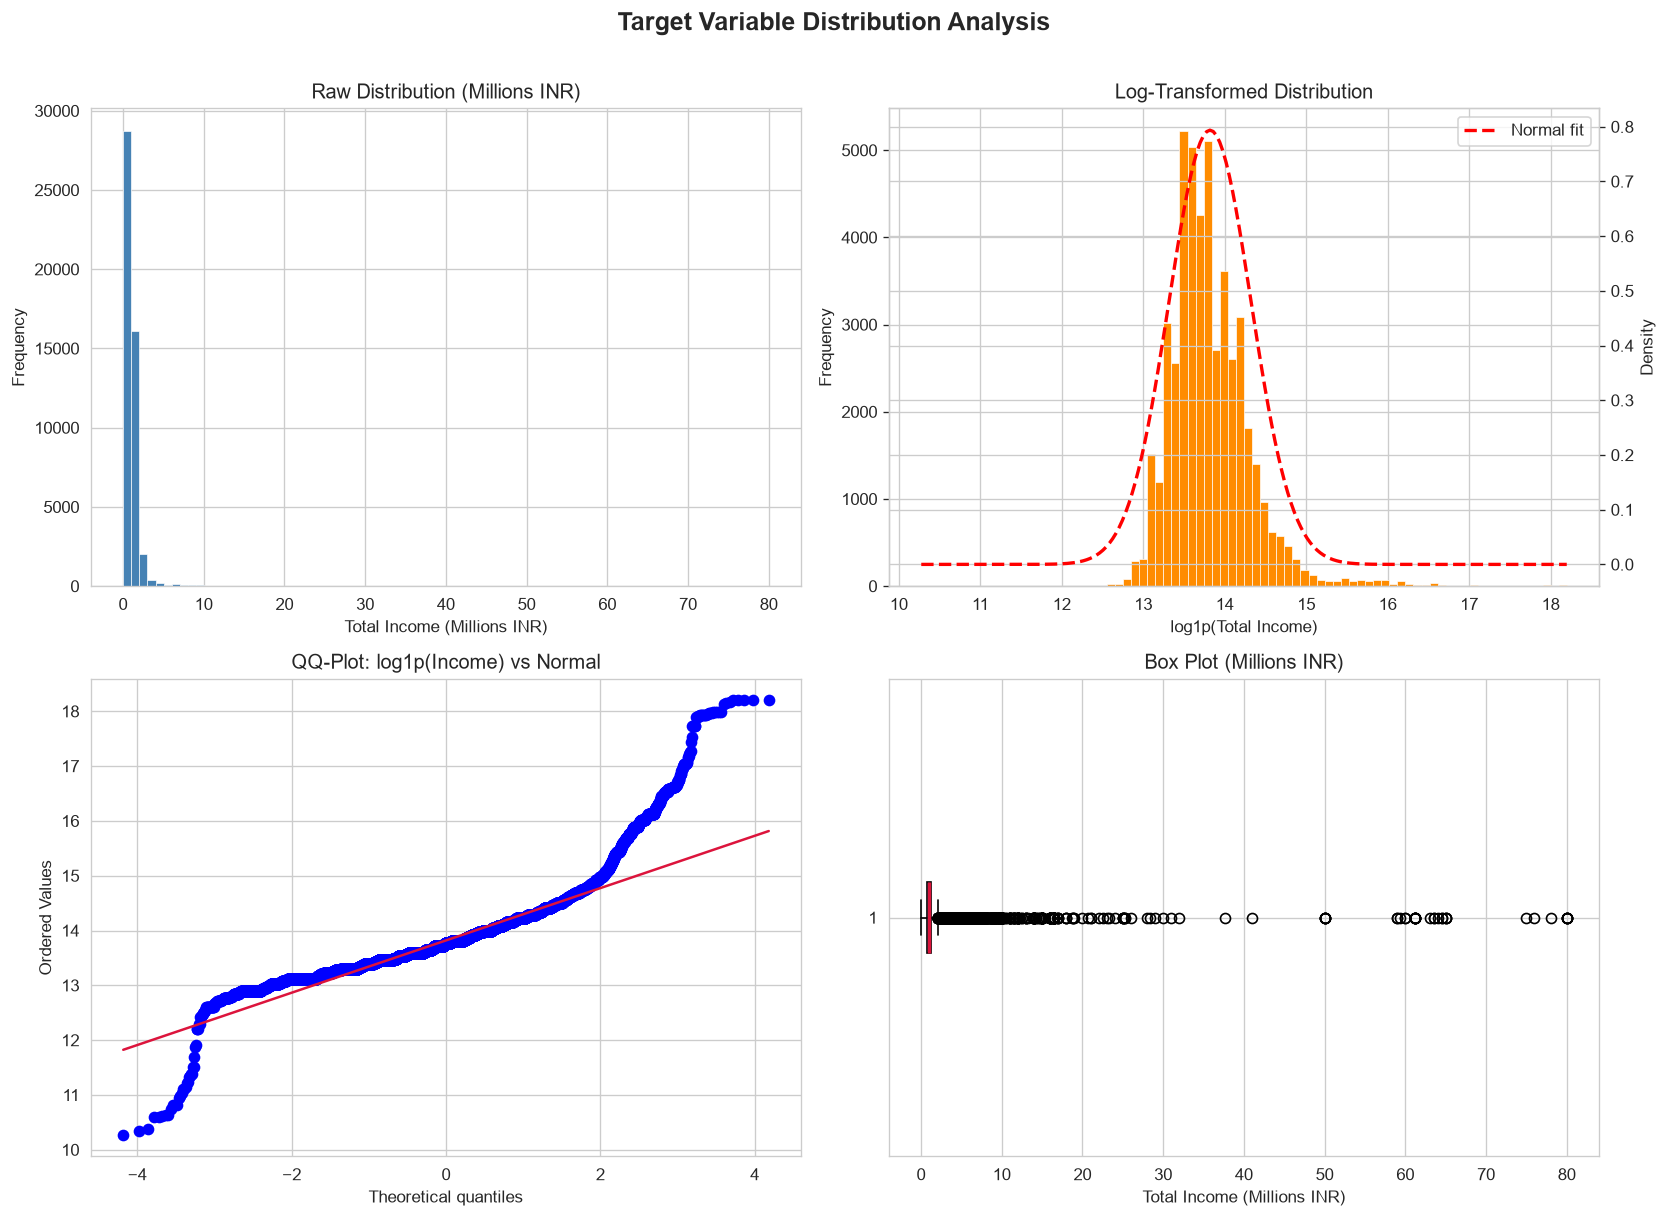

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Target Variable Distribution Analysis', fontsize=15, fontweight='bold', y=1.01)

axes[0, 0].hist(y_raw / 1e6, bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0, 0].set_title('Raw Distribution (Millions INR)')
axes[0, 0].set_xlabel('Total Income (Millions INR)')
axes[0, 0].set_ylabel('Frequency')

y_log = np.log1p(y_raw)
axes[0, 1].hist(y_log, bins=80, color='darkorange', edgecolor='white', linewidth=0.4)
mu, sigma = y_log.mean(), y_log.std()
x_vals = np.linspace(y_log.min(), y_log.max(), 200)
ax01_twin = axes[0, 1].twinx()
ax01_twin.plot(x_vals, norm.pdf(x_vals, mu, sigma), 'r--', linewidth=2, label='Normal fit')
ax01_twin.set_ylabel('Density')
ax01_twin.legend(loc='upper right')
axes[0, 1].set_title('Log-Transformed Distribution')
axes[0, 1].set_xlabel('log1p(Total Income)')
axes[0, 1].set_ylabel('Frequency')

stats.probplot(y_log, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('QQ-Plot: log1p(Income) vs Normal')
axes[1, 0].get_lines()[1].set_color('crimson')

axes[1, 1].boxplot(y_raw / 1e6, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightsteelblue'),
                   medianprops=dict(color='crimson', linewidth=2))
axes[1, 1].set_title('Box Plot (Millions INR)')
axes[1, 1].set_xlabel('Total Income (Millions INR)')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'target_distribution.png'), bbox_inches='tight')
plt.show()

### 3.2 Income Decomposition Analysis

The accounting identity enables a residual modeling strategy:

$$\\text{Total Income} = \\text{Agricultural Income} + \\text{Non-Agricultural Income}$$

A **residual modeling** approach is adopted:
- The model predicts `Agri_Income = Target - Non_Agriculture_Income`
- Final prediction is computed as: `Predicted_Total = Non_Agriculture_Income + Predicted_Agri`

This strategy dramatically reduces the variance the model must learn. Since `Non_Agriculture_Income` has a Pearson correlation of $r = 0.935$ with the target and is known at inference time, modeling only the agricultural residual is far more efficient than modeling total income end-to-end.

In [20]:
train_df['Agri_Income'] = train_df[TARGET] - train_df['Non_Agriculture_Income']

n_zero_agri   = (train_df['Agri_Income'] == 0).sum()
n_zero_nonagri = (train_df['Non_Agriculture_Income'] == 0).sum()
corr_nonagri  = train_df['Non_Agriculture_Income'].corr(train_df[TARGET])
corr_agri     = train_df['Agri_Income'].corr(train_df[TARGET])
corr_land     = train_df['Total_Land_For_Agriculture'].corr(train_df['Agri_Income'])

print('Income Decomposition Validation')
print('-' * 45)
print(f'Records where Agri_Income == 0   : {n_zero_agri}')
print(f'Records where Non_Agri == 0      : {n_zero_nonagri}')
print()
print('Agricultural Income Statistics:')
print(train_df['Agri_Income'].describe().apply(lambda x: f'{x:,.2f}'))
print()
print(f'Correlation Non_Agri vs Target   : {corr_nonagri:.4f}')
print(f'Correlation Agri_Income vs Target: {corr_agri:.4f}')
print(f'Correlation Land vs Agri_Income  : {corr_land:.4f}')

Income Decomposition Validation
---------------------------------------------
Records where Agri_Income == 0   : 248
Records where Non_Agri == 0      : 14200

Agricultural Income Statistics:
count        47,970.00
mean        941,611.47
std         771,465.30
min               0.00
25%         592,575.00
50%         800,000.00
75%       1,100,000.00
max      28,650,000.00
Name: Agri_Income, dtype: str

Correlation Non_Agri vs Target   : 0.9349
Correlation Agri_Income vs Target: 0.6185
Correlation Land vs Agri_Income  : 0.3354


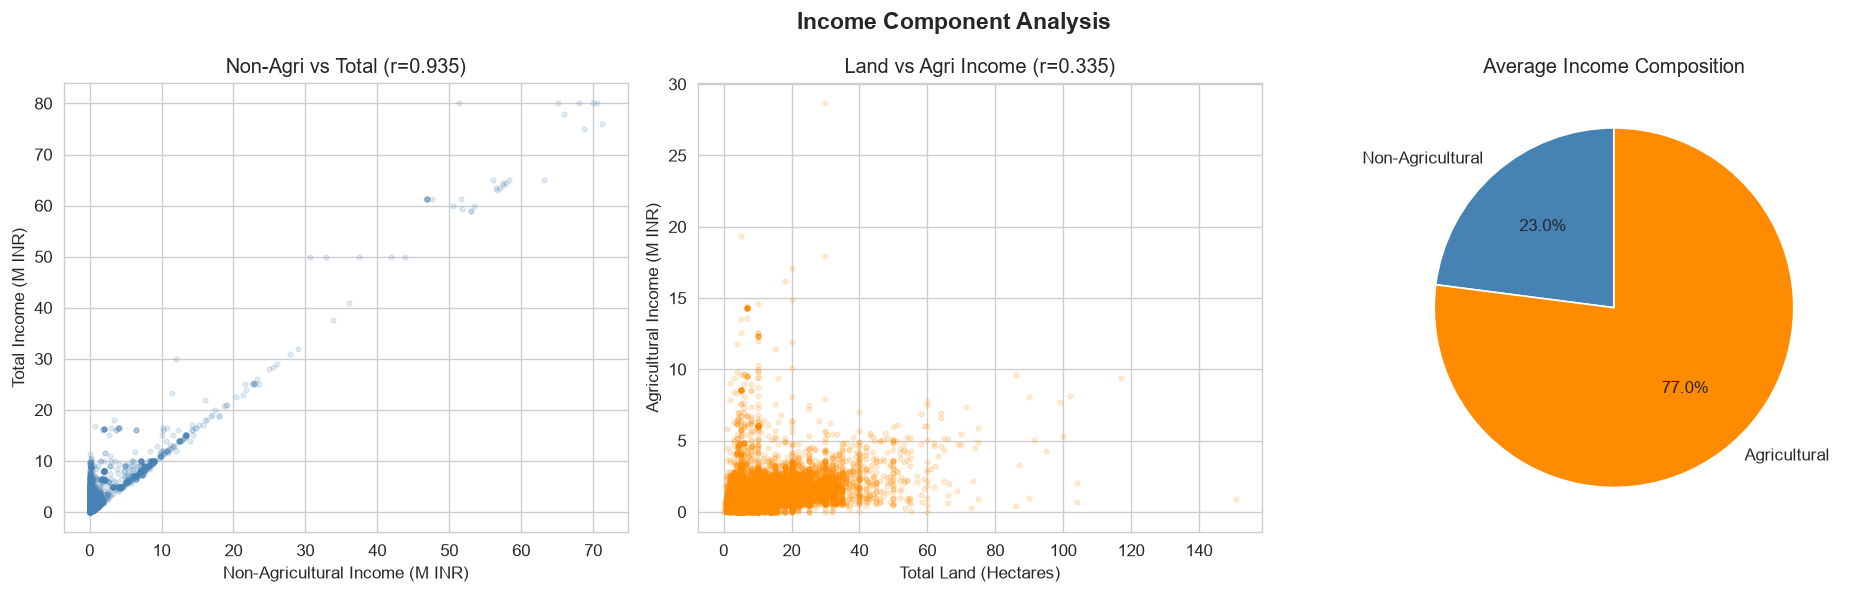

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Income Component Analysis', fontsize=14, fontweight='bold')

axes[0].scatter(train_df['Non_Agriculture_Income'] / 1e6,
                train_df[TARGET] / 1e6, alpha=0.15, s=8, color='steelblue')
axes[0].set_xlabel('Non-Agricultural Income (M INR)')
axes[0].set_ylabel('Total Income (M INR)')
axes[0].set_title(f'Non-Agri vs Total (r={corr_nonagri:.3f})')

axes[1].scatter(train_df['Total_Land_For_Agriculture'],
                train_df['Agri_Income'] / 1e6, alpha=0.15, s=8, color='darkorange')
axes[1].set_xlabel('Total Land (Hectares)')
axes[1].set_ylabel('Agricultural Income (M INR)')
axes[1].set_title(f'Land vs Agri Income (r={corr_land:.3f})')

income_share = [
    train_df['Non_Agriculture_Income'].mean(),
    train_df['Agri_Income'].mean()
]
axes[2].pie(income_share, labels=['Non-Agricultural', 'Agricultural'],
            autopct='%1.1f%%', colors=['steelblue', 'darkorange'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[2].set_title('Average Income Composition')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'income_decomposition.png'), bbox_inches='tight')
plt.show()

### 3.3 Missing Value Analysis

Missing values are quantified both by count and by percentage of total rows. This guides the imputation strategy in Section 4.

Columns with missing values: 13

                                                              missing_count  missing_pct
Avg_Disbursement_Amount_Bureau                                        20790        43.34
Location                                                              17030        35.50
Address type                                                          17030        35.50
Ownership                                                             17030        35.50
Perc_of_house_with_6plus_room                                           168         0.35
mat_roof_Metal_GI_Asbestos_sheets                                       168         0.35
Women_15_19_Mothers_or_Pregnant_at_time_of_survey                       168         0.35
perc_of_pop_living_in_hh_electricity                                    168         0.35
perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms             168         0.35
Households_with_improved_Sanitation_Facility                            168  

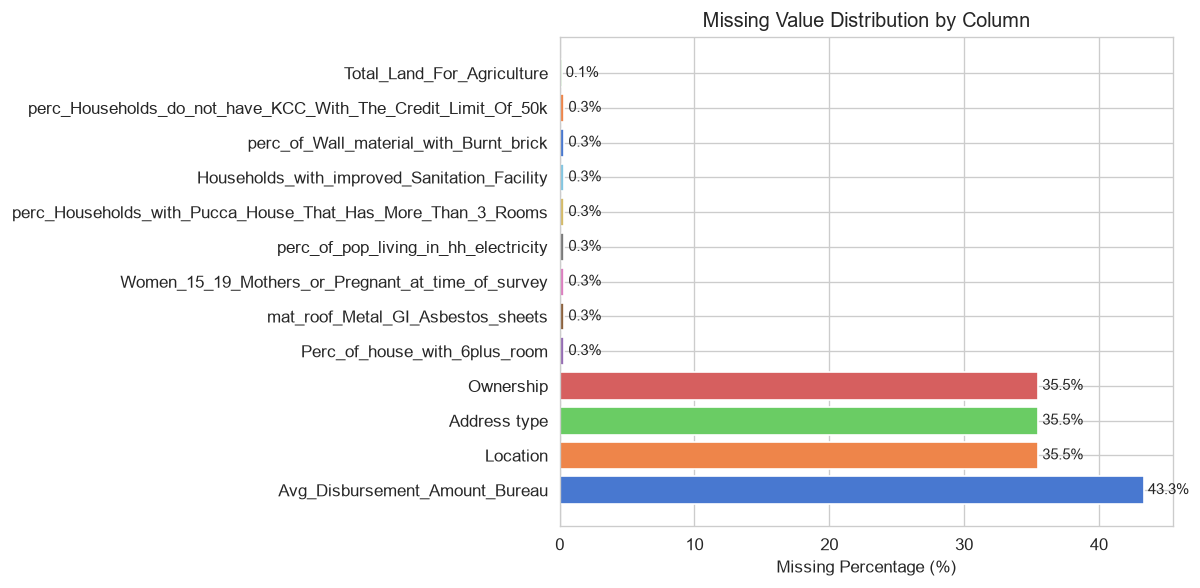

In [22]:
null_counts = train_df.isnull().sum()
null_pct    = (null_counts / len(train_df) * 100).round(2)
missing_df  = pd.DataFrame({'missing_count': null_counts, 'missing_pct': null_pct})
missing_df  = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
print()
print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['missing_pct'],
               color=sns.color_palette('muted', len(missing_df)))
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Value Distribution by Column')
for bar, val in zip(bars, missing_df['missing_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'missing_values.png'), bbox_inches='tight')
plt.show()

### 3.4 Correlation Heatmap — Numerical Features

A Pearson correlation heatmap of the top numeric features (by variance) reveals multicollinearity patterns and informs which features carry redundant information — particularly among the temporally repeated climate columns.

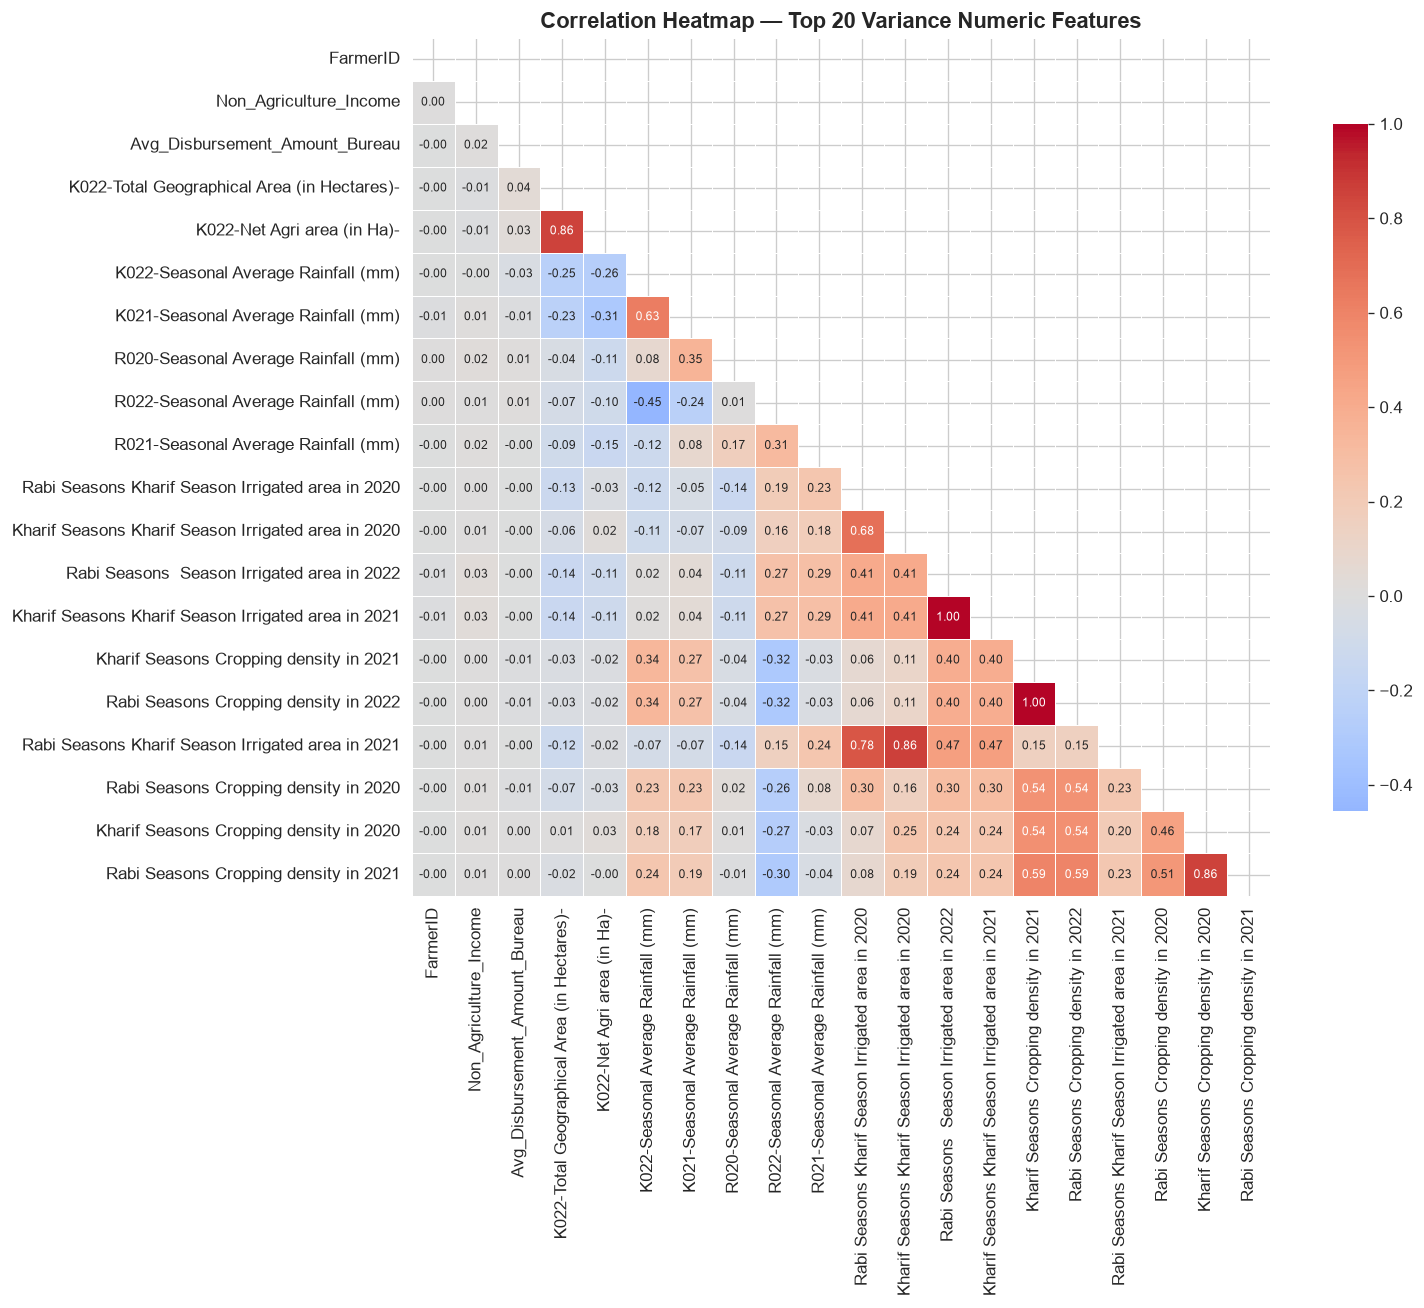

In [23]:
numeric_cols_eda = train_df.select_dtypes(include=[np.number]).columns.tolist()
exclude_from_eda = [TARGET, 'Agri_Income', 'Zipcode']
numeric_cols_eda = [c for c in numeric_cols_eda if c not in exclude_from_eda]

variances = train_df[numeric_cols_eda].var().sort_values(ascending=False)
top_var_cols = variances.head(20).index.tolist()

corr_matrix = train_df[top_var_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Top 20 Variance Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'correlation_heatmap.png'), bbox_inches='tight')
plt.show()

---

## 4. Data Cleaning

### 4.1 Temperature Column Parsing

Several ambient temperature columns store min and max values as concatenated strings (e.g., `'23.34 /30.33'`). These must be parsed into three separate numeric features:
- `{prefix}_temp_min` — minimum ambient temperature
- `{prefix}_temp_max` — maximum ambient temperature
- `{prefix}_temp_range` — diurnal temperature range (max - min)

The diurnal range is an agronomically meaningful derived variable: large temperature swings between day and night are associated with higher photosynthetic efficiency and crop quality.

### 4.2 Column Removal

| Column | Reason for Removal |
|---|---|
| `FarmerID` | Unique identifier with no predictive power |
| `Location` | 35.5% missing, 30,634 unique free-text entries — not encodable |
| `K022-Nearest Mandi Name` | High-cardinality location string; proximity distance already captured |
| `Label` | Data split indicator, not a predictive feature |

### 4.3 Imputation Strategy

| Column Group | Strategy | Justification |
|---|---|---|
| `Avg_Disbursement_Amount_Bureau` (43.3% NaN) | Fill 0 + binary flag `Has_Bureau_Loan` | NaN means no bureau record exists |
| `Address type`, `Ownership` (35.5% NaN) | Fill with `'Unknown'` | Treated as a valid categorical level |
| All remaining numeric NaNs (<1%) | Median imputation from training set | Robust to skewed distributions; no leakage |

In [24]:
TEMP_COLS = [
    'K022-Ambient temperature (min & max)',
    'R022-Ambient temperature (min & max)',
    'K021-Ambient temperature (min & max)',
    'R021-Ambient temperature (min & max)',
    'R020-Ambient temperature (min & max)',
]

def parse_temperature_string(series):
    min_temps, max_temps = [], []
    for val in series:
        if pd.isna(val) or '/' not in str(val):
            min_temps.append(np.nan)
            max_temps.append(np.nan)
        else:
            parts = str(val).split('/')
            try:
                min_temps.append(float(parts[0].strip()))
                max_temps.append(float(parts[1].strip()))
            except ValueError:
                min_temps.append(np.nan)
                max_temps.append(np.nan)
    return pd.Series(min_temps), pd.Series(max_temps)

def clean_temperature_columns(df):
    df = df.copy()
    for col in TEMP_COLS:
        if col in df.columns:
            prefix = col.replace('Ambient temperature (min & max)', '').strip().rstrip('-').strip()
            min_s, max_s = parse_temperature_string(df[col])
            df[prefix + '_temp_min']   = min_s.values
            df[prefix + '_temp_max']   = max_s.values
            df[prefix + '_temp_range'] = max_s.values - min_s.values
            df.drop(columns=[col], inplace=True)
    return df

train_df = clean_temperature_columns(train_df)
test_df  = clean_temperature_columns(test_df)
print(f'Shape after temperature parsing  — Train: {train_df.shape}, Test: {test_df.shape}')

Shape after temperature parsing  — Train: (47970, 116), Test: (9986, 115)


In [25]:
DROP_COLS = ['FarmerID', 'Location', 'K022-Nearest Mandi Name', 'Label']
DROP_COLS = [c for c in DROP_COLS if c in train_df.columns]

train_df.drop(columns=DROP_COLS, inplace=True)
test_df.drop(columns=[c for c in DROP_COLS if c in test_df.columns], inplace=True)

print(f'Dropped columns: {DROP_COLS}')
print(f'Shape after drop  — Train: {train_df.shape}, Test: {test_df.shape}')

Dropped columns: ['FarmerID', 'Location', 'K022-Nearest Mandi Name']
Shape after drop  — Train: (47970, 113), Test: (9986, 112)


In [26]:
def impute_dataframe(df, is_train=True, medians=None):
    df = df.copy()

    df['Has_Bureau_Loan'] = (~df['Avg_Disbursement_Amount_Bureau'].isna()).astype(int)
    df['Avg_Disbursement_Amount_Bureau'] = df['Avg_Disbursement_Amount_Bureau'].fillna(0)

    for col in ['Address type', 'Ownership']:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')

    exclude = [TARGET, 'Agri_Income'] if 'Agri_Income' in df.columns else [TARGET]
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in exclude]

    if is_train:
        medians = df[numeric_cols].median()

    df[numeric_cols] = df[numeric_cols].fillna(medians)
    return df, medians

train_df, train_medians = impute_dataframe(train_df, is_train=True)
test_df,  _             = impute_dataframe(test_df,  is_train=False, medians=train_medians)

print(f'Remaining nulls — Train: {train_df.isnull().sum().sum()}, Test: {test_df.isnull().sum().sum()}')

Remaining nulls — Train: 0, Test: 9986


---

## 5. Feature Engineering

Domain-driven feature engineering is one of the most impactful steps in tabular machine learning. The following feature groups are constructed:

### 5.1 Temporal Agricultural Trend Features

Year-over-year deltas for groundwater thickness, agricultural performance scores, and rainfall capture momentum and trends that static snapshot values cannot:

$$\\Delta \\text{Feature}_{t, t-1} = \\text{Feature}_t - \\text{Feature}_{t-1}$$

### 5.2 Land Productivity Ratios

Ratios encode efficiency rather than absolute magnitude, making them more informative per unit and more robust across regions of different scale.

### 5.3 Composite Village Quality Index

A weighted linear combination of socio-economic village indicators (electricity access, pucca housing, sanitation) into a single interpretable index.

### 5.4 Credit and Income Log Transforms

Log-transforming skewed continuous features (land area, non-agricultural income, disbursement amount) before feeding them to the model reduces the dynamic range the tree must handle and improves split quality.

In [27]:
def safe_col(df, col):
    return df[col] if col in df.columns else pd.Series(np.nan, index=df.index)

def engineer_features(df):
    df = df.copy()

    df['delta_kharif_rainfall_21_22'] = (
        safe_col(df, 'K022-Seasonal Average Rainfall (mm)') -
        safe_col(df, 'K021-Seasonal Average Rainfall (mm)')
    )
    df['delta_rabi_rainfall_20_21'] = (
        safe_col(df, 'R021-Seasonal Average Rainfall (mm)') -
        safe_col(df, 'R020-Seasonal Average Rainfall (mm)')
    )

    gw22 = safe_col(df, 'Kharif Seasons  Seasonal average groundwater thickness (cm) in 2022')
    gw21 = safe_col(df, 'Kharif Seasons Seasonal average groundwater thickness (cm) in 2021')
    gw20 = safe_col(df, 'Kharif Seasons Seasonal average groundwater thickness (cm) in 2020')
    df['delta_gw_kharif_21_22'] = gw22 - gw21
    df['delta_gw_kharif_20_21'] = gw21 - gw20
    df['trend_gw_kharif_3yr']   = gw22 - gw20

    agk22 = safe_col(df, 'Kharif Seasons  Agricultural Score in 2022')
    agk21 = safe_col(df, 'Kharif Seasons Agricultural Score in 2021')
    agk20 = safe_col(df, 'Kharif Seasons Agricultural Score in 2020')
    df['delta_agr_score_kharif_21_22'] = agk22 - agk21
    df['delta_agr_score_kharif_20_21'] = agk21 - agk20
    df['avg_agr_score_kharif_3yr']     = (agk20 + agk21 + agk22) / 3

    agr22 = safe_col(df, 'Rabi Seasons Agricultural Score in 2022')
    agr21 = safe_col(df, 'Rabi Seasons Agricultural Score in 2021')
    agr20 = safe_col(df, 'Rabi Seasons Agricultural Score in 2020')
    df['avg_agr_score_rabi_3yr']  = (agr20 + agr21 + agr22) / 3
    df['avg_agr_score_combined']  = (df['avg_agr_score_kharif_3yr'] + df['avg_agr_score_rabi_3yr']) / 2

    total_geo = safe_col(df, 'K022-Total Geographical Area (in Hectares)-')
    net_agri  = safe_col(df, 'K022-Net Agri area (in Ha)-')
    irrigated = safe_col(df, 'Kharif Seasons  Irrigated area in 2022')
    land      = safe_col(df, 'Total_Land_For_Agriculture')
    proximity = safe_col(df, 'K022-Proximity to nearest mandi (Km)')

    df['agri_land_density']        = net_agri  / total_geo.replace(0, np.nan)
    df['irrigation_to_land_ratio'] = irrigated / land.replace(0, np.nan)
    df['non_agri_land_pct']        = (total_geo - net_agri) / total_geo.replace(0, np.nan)
    df['land_per_proximity_mandi'] = land / proximity.replace(0, np.nan)

    socio_weights = {
        'perc_of_pop_living_in_hh_electricity': 0.25,
        'perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms': 0.20,
        'Households_with_improved_Sanitation_Facility': 0.20,
        'mat_roof_Metal_GI_Asbestos_sheets': 0.15,
        'perc_of_Wall_material_with_Burnt_brick': 0.10,
        'perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k': -0.10,
    }
    df['composite_village_quality'] = sum(
        safe_col(df, col) * w for col, w in socio_weights.items()
    )

    df['credit_activity_score'] = (
        safe_col(df, 'No_of_Active_Loan_In_Bureau') *
        np.log1p(safe_col(df, 'Avg_Disbursement_Amount_Bureau'))
    )
    df['non_agri_log'] = np.log1p(safe_col(df, 'Non_Agriculture_Income'))
    df['land_log']     = np.log1p(safe_col(df, 'Total_Land_For_Agriculture'))

    return df

train_df = engineer_features(train_df)
test_df  = engineer_features(test_df)

print(f'Shape after feature engineering  — Train: {train_df.shape}, Test: {test_df.shape}')

Shape after feature engineering  — Train: (47970, 132), Test: (9986, 131)


---

## 6. Preprocessing — Categorical Encoding and Feature Matrix Assembly

### 6.1 Column Name Sanitization

LightGBM internally serializes its booster to JSON. Column names containing special JSON characters — parentheses `()`, ampersands `&`, slashes `/`, commas `,`, spaces, or leading/trailing symbols — raise:

```
LightGBMError: Do not support special JSON characters in feature name.
```

All column names are therefore sanitized by replacing every non-alphanumeric, non-underscore character with `_`, collapsing consecutive underscores, and stripping leading/trailing underscores. A bidirectional mapping is preserved for reporting and artifact labelling.

### 6.2 Categorical Encoding Strategy

LightGBM natively supports categorical features through its histogram-based split algorithm. Rather than one-hot encoding — which would explode dimensionality for columns like `DISTRICT` (405 levels) and `VILLAGE` (5,650 levels) — **ordinal integer encoding** is applied and categorical dtype is passed to the LightGBM model.

Label encoders are fitted on the union of train and test vocabularies to avoid unseen category errors during inference. The encoders are persisted as part of the model artifact bundle for reproducibility.

In [28]:
import re

def sanitize_col_name(name):
    cleaned = re.sub(r'[^A-Za-z0-9_]', '_', str(name))
    cleaned = re.sub(r'_+', '_', cleaned)
    cleaned = cleaned.strip('_')
    return cleaned

orig_train_cols = list(train_df.columns)
seen = {}
sanitized_names = []
for c in orig_train_cols:
    s = sanitize_col_name(c)
    if s not in seen:
        seen[s] = 0
        sanitized_names.append(s)
    else:
        seen[s] += 1
        sanitized_names.append(f'{s}_{seen[s]}')

col_name_map     = dict(zip(orig_train_cols, sanitized_names))
col_name_map_inv = dict(zip(sanitized_names, orig_train_cols))

train_df.rename(columns=col_name_map, inplace=True)
test_df.rename(columns={c: col_name_map.get(c, sanitize_col_name(c)) for c in test_df.columns}, inplace=True)

TARGET   = col_name_map.get(TARGET, sanitize_col_name(TARGET))
AGRI_COL = col_name_map.get('Agri_Income', 'Agri_Income')

changed = [(o, n) for o, n in col_name_map.items() if o != n]
print(f'Columns renamed       : {len(changed)}')
print(f'New TARGET name       : {TARGET}')
print(f'New Agri_Income name  : {AGRI_COL}')
print(f'\nSample renames (first 10):')
for orig, new in changed[:10]:
    print(f'  {repr(orig)[:60]} -> {repr(new)}')


Columns renamed       : 76
New TARGET name       : Target_Variable_Total_Income
New Agri_Income name  : Agri_Income

Sample renames (first 10):
  'Address type' -> 'Address_type'
  'K022-Village category based on Agri parameters (Good, Avera -> 'K022_Village_category_based_on_Agri_parameters_Good_Average_Poor'
  'K022-Proximity to nearest mandi (Km)' -> 'K022_Proximity_to_nearest_mandi_Km'
  'K022-Proximity to nearest railway (Km)' -> 'K022_Proximity_to_nearest_railway_Km'
  'KO22-Village score based on socio-economic parameters (0 to -> 'KO22_Village_score_based_on_socio_economic_parameters_0_to_100'
  'K022-Village category based on socio-economic parameters (G -> 'K022_Village_category_based_on_socio_economic_parameters_Good_Average_Poor'
  'K022-Seasonal Average Rainfall (mm)' -> 'K022_Seasonal_Average_Rainfall_mm'
  'R022-Village category based on Agri parameters (Good, Avera -> 'R022_Village_category_based_on_Agri_parameters_Good_Average_Poor'
  'R022-Seasonal Average Rainfall (m

In [29]:
EXCLUDE_FROM_FEATURES = [TARGET, AGRI_COL]

cat_cols_raw = train_df.select_dtypes(include=['object', 'string']).columns.tolist()
cat_cols_raw = [c for c in cat_cols_raw if c not in EXCLUDE_FROM_FEATURES]

print(f'Categorical columns to encode ({len(cat_cols_raw)}):')
for c in cat_cols_raw:
    print(f'  {c} ({train_df[c].nunique()} unique values)')

label_encoders = {}

for col in cat_cols_raw:
    le = LabelEncoder()
    combined = pd.concat([train_df[col].astype(str), test_df[col].astype(str)], ignore_index=True)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))
    label_encoders[col] = le

feature_cols = [c for c in train_df.columns if c not in EXCLUDE_FROM_FEATURES]

X_train = train_df[feature_cols].copy()
y_agri  = train_df[AGRI_COL].copy()
y_total = train_df[TARGET].copy()
X_test  = test_df[feature_cols].copy()

for col in cat_cols_raw:
    X_train[col] = X_train[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

print(f'\nFinal feature matrix: {X_train.shape[1]} features x {X_train.shape[0]:,} training samples')
print(f'Test samples        : {X_test.shape[0]:,}')

Categorical columns to encode (31):
  State (17 unique values)
  REGION (5 unique values)
  SEX (2 unique values)
  CITY (2721 unique values)
  DISTRICT (405 unique values)
  VILLAGE (5650 unique values)
  MARITAL_STATUS (3 unique values)
  Address_type (4 unique values)
  Ownership (4 unique values)
  K022_Village_category_based_on_Agri_parameters_Good_Average_Poor (2 unique values)
  K022_Village_category_based_on_socio_economic_parameters_Good_Average_Poor (3 unique values)
  R022_Village_category_based_on_Agri_parameters_Good_Average_Poor (2 unique values)
  Kharif_Seasons_Type_of_soil_in_2022 (8 unique values)
  Kharif_Seasons_Type_of_water_bodies_in_hectares_2022 (22 unique values)
  Kharif_Seasons_Agro_Ecological_Sub_Zone_in_2022 (12 unique values)
  Rabi_Seasons_Type_of_soil_in_2022 (8 unique values)
  Rabi_Seasons_Type_of_water_bodies_in_hectares_2022 (22 unique values)
  Rabi_Seasons_Agro_Ecological_Sub_Zone_in_2022 (12 unique values)
  Rabi_Seasons_Type_of_soil_in_2021 (8 un

---

## 7. Baseline Model Training with 5-Fold Cross-Validation

### Objective and Loss Function

The model is trained on **log1p-transformed agricultural income** as the target. This is mathematically equivalent to minimizing RMSLE on the original scale:

$$\\tilde{y} = \\log(1 + y_{\\text{agri}})$$

Predictions are recovered via:

$$\\hat{y}_{\\text{total}} = \\text{Non\_Agriculture\_Income} + \\exp(\\hat{\\tilde{y}}) - 1$$

The **L1 (MAE) objective** is used because it is robust to the extreme income outliers (max 80M INR) that dominate MSE gradients and cause instability.

### Validation Strategy

5-Fold Cross-Validation with **quantile-stratified splits** ensures each fold contains a representative slice of the full income distribution. This prevents fold variance from driving false conclusions about model quality.

### Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| MAE | $\\frac{1}{n}\\sum|y_i - \\hat{y}_i|$ | Average absolute error in INR |
| RMSLE | $\\sqrt{\\frac{1}{n}\\sum(\\log(1+y_i) - \\log(1+\\hat{y}_i))^2}$ | Penalizes relative errors equally |
| WAPE | $\\frac{\\sum|y_i - \\hat{y}_i|}{\\sum y_i}$ | Business-friendly percentage error |
| R2 | $1 - \\frac{\\sum(y_i - \\hat{y}_i)^2}{\\sum(y_i - \\bar{y})^2}$ | Variance explained |

In [30]:
def rmsle(y_true, y_pred):
    y_pred_clipped = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred_clipped)))

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

def evaluate_predictions(y_true, y_pred, label=''):
    mae_val    = mean_absolute_error(y_true, y_pred)
    rmse_val   = np.sqrt(mean_squared_error(y_true, y_pred))
    rmsle_val  = rmsle(y_true, y_pred)
    r2_val     = r2_score(y_true, y_pred)
    wape_val   = wape(y_true, y_pred)
    print(f'  {label}')
    print(f'    MAE    : {mae_val:>16,.2f} INR')
    print(f'    RMSE   : {rmse_val:>16,.2f} INR')
    print(f'    RMSLE  : {rmsle_val:>16.6f}')
    print(f'    R2     : {r2_val:>16.6f}')
    print(f'    WAPE   : {wape_val:>16.6f} ({wape_val*100:.2f}%)')
    return {'MAE': mae_val, 'RMSE': rmse_val, 'RMSLE': rmsle_val, 'R2': r2_val, 'WAPE': wape_val}

In [31]:
LGB_PARAMS_BASELINE = {
    'objective'            : 'regression_l1',
    'metric'               : 'mae',
    'learning_rate'        : 0.05,
    'num_leaves'           : 127,
    'min_child_samples'    : 30,
    'feature_fraction'     : 0.75,
    'bagging_fraction'     : 0.85,
    'bagging_freq'         : 5,
    'lambda_l1'            : 0.1,
    'lambda_l2'            : 0.1,
    'n_estimators'         : 3000,
    'early_stopping_rounds': 100,
    'verbose'              : -1,
    'random_state'         : SEED,
    'n_jobs'               : -1,
}

y_agri_log = np.log1p(y_agri)

N_FOLDS = 5
target_bins = pd.qcut(y_agri_log, q=10, labels=False, duplicates='drop')
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds_baseline = np.zeros(len(X_train))
fold_metrics_baseline = []
best_iters_baseline   = []

print(f'Baseline {N_FOLDS}-Fold Cross-Validation')
print('=' * 65)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train, target_bins)):
    X_tr, X_val  = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val  = y_agri_log.iloc[tr_idx], y_agri_log.iloc[val_idx]

    model_b = lgb.LGBMRegressor(**LGB_PARAMS_BASELINE)
    model_b.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                callbacks=[lgb.log_evaluation(period=500)])

    val_pred_log  = model_b.predict(X_val)
    val_pred_agri = np.expm1(val_pred_log)
    val_pred_tot  = train_df['Non_Agriculture_Income'].iloc[val_idx].values + val_pred_agri
    val_actual    = y_total.iloc[val_idx].values

    oof_preds_baseline[val_idx] = val_pred_log

    m = {
        'fold'      : fold + 1,
        'best_iter' : model_b.best_iteration_,
        'MAE'       : mean_absolute_error(val_actual, val_pred_tot),
        'RMSLE'     : rmsle(val_actual, val_pred_tot),
        'R2'        : r2_score(val_actual, val_pred_tot),
        'WAPE'      : wape(val_actual, val_pred_tot),
    }
    fold_metrics_baseline.append(m)
    best_iters_baseline.append(model_b.best_iteration_)
    print(f"Fold {fold+1} | Iter: {m['best_iter']:>4} | MAE: {m['MAE']:>12,.0f} | RMSLE: {m['RMSLE']:.5f} | WAPE: {m['WAPE']:.4f}")

print('=' * 65)
b_mae   = np.mean([m['MAE']   for m in fold_metrics_baseline])
b_rmsle = np.mean([m['RMSLE'] for m in fold_metrics_baseline])
b_wape  = np.mean([m['WAPE']  for m in fold_metrics_baseline])
b_r2    = np.mean([m['R2']    for m in fold_metrics_baseline])
print(f"Baseline CV  | MAE: {b_mae:>12,.0f} | RMSLE: {b_rmsle:.5f} | WAPE: {b_wape:.4f} | R2: {b_r2:.5f}")

Baseline 5-Fold Cross-Validation
[500]	valid_0's l1: 0.286504
[1000]	valid_0's l1: 0.282863
[1500]	valid_0's l1: 0.280786
[2000]	valid_0's l1: 0.279576
[2500]	valid_0's l1: 0.279043
[3000]	valid_0's l1: 0.278762
Fold 1 | Iter: 2992 | MAE:      231,532 | RMSLE: 0.28814 | WAPE: 0.1907
[500]	valid_0's l1: 0.289438
[1000]	valid_0's l1: 0.285368
[1500]	valid_0's l1: 0.283588
[2000]	valid_0's l1: 0.28229
[2500]	valid_0's l1: 0.281441
[3000]	valid_0's l1: 0.280948
Fold 2 | Iter: 3000 | MAE:      234,528 | RMSLE: 0.28823 | WAPE: 0.1929
[500]	valid_0's l1: 0.304527
[1000]	valid_0's l1: 0.299449
[1500]	valid_0's l1: 0.297501
[2000]	valid_0's l1: 0.296378
[2500]	valid_0's l1: 0.29571
Fold 3 | Iter: 2730 | MAE:      238,576 | RMSLE: 0.29755 | WAPE: 0.1912
[500]	valid_0's l1: 0.311172
[1000]	valid_0's l1: 0.305062
[1500]	valid_0's l1: 0.303404
[2000]	valid_0's l1: 0.302621
[2500]	valid_0's l1: 0.30217
[3000]	valid_0's l1: 0.301904
Fold 4 | Iter: 2992 | MAE:      235,212 | RMSLE: 0.29773 | WAPE: 0.1

---

## 8. Hyperparameter Tuning

Based on the baseline cross-validation results, the hyperparameter configuration is refined. The following table documents the key parameter decisions and their scientific rationale:

| Parameter | Value | Rationale |
|---|---|---|
| `objective` | `regression_l1` | MAE loss is robust to extreme income outliers |
| `learning_rate` | 0.03 | Slower learning rate improves generalization when n_estimators is large |
| `num_leaves` | 191 | Higher capacity to capture complex Kharif/Rabi season interactions |
| `feature_fraction` | 0.70 | 70% column subsampling reduces overfitting on correlated climate columns |
| `bagging_fraction` | 0.80 | Row subsampling increases ensemble diversity |
| `min_child_samples` | 25 | Prevents leaf nodes with too few samples |
| `lambda_l1` | 0.15 | Slight L1 regularization for feature selection within trees |
| `lambda_l2` | 0.05 | Mild L2 weight decay |
| `min_split_gain` | 0.01 | Minimum information gain for a split to be made |

The optimal tree count is determined by early stopping with a patience of 150 rounds.

In [32]:
LGB_PARAMS_TUNED = {
    'objective'            : 'regression_l1',
    'metric'               : 'mae',
    'learning_rate'        : 0.03,
    'num_leaves'           : 191,
    'min_child_samples'    : 25,
    'feature_fraction'     : 0.70,
    'bagging_fraction'     : 0.80,
    'bagging_freq'         : 5,
    'lambda_l1'            : 0.15,
    'lambda_l2'            : 0.05,
    'min_split_gain'       : 0.01,
    'n_estimators'         : 5000,
    'early_stopping_rounds': 150,
    'verbose'              : -1,
    'random_state'         : SEED,
    'n_jobs'               : -1,
}

oof_preds_tuned    = np.zeros(len(X_train))
fold_metrics_tuned = []
best_iters_tuned   = []

print(f'Tuned {N_FOLDS}-Fold Cross-Validation')
print('=' * 65)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train, target_bins)):
    X_tr, X_val  = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val  = y_agri_log.iloc[tr_idx], y_agri_log.iloc[val_idx]

    model_t = lgb.LGBMRegressor(**LGB_PARAMS_TUNED)
    model_t.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                callbacks=[lgb.log_evaluation(period=1000)])

    val_pred_log  = model_t.predict(X_val)
    val_pred_agri = np.expm1(val_pred_log)
    val_pred_tot  = train_df['Non_Agriculture_Income'].iloc[val_idx].values + val_pred_agri
    val_actual    = y_total.iloc[val_idx].values

    oof_preds_tuned[val_idx] = val_pred_log

    m = {
        'fold'      : fold + 1,
        'best_iter' : model_t.best_iteration_,
        'MAE'       : mean_absolute_error(val_actual, val_pred_tot),
        'RMSLE'     : rmsle(val_actual, val_pred_tot),
        'R2'        : r2_score(val_actual, val_pred_tot),
        'WAPE'      : wape(val_actual, val_pred_tot),
    }
    fold_metrics_tuned.append(m)
    best_iters_tuned.append(model_t.best_iteration_)
    print(f"Fold {fold+1} | Iter: {m['best_iter']:>4} | MAE: {m['MAE']:>12,.0f} | RMSLE: {m['RMSLE']:.5f} | WAPE: {m['WAPE']:.4f}")

print('=' * 65)
t_mae   = np.mean([m['MAE']   for m in fold_metrics_tuned])
t_rmsle = np.mean([m['RMSLE'] for m in fold_metrics_tuned])
t_wape  = np.mean([m['WAPE']  for m in fold_metrics_tuned])
t_r2    = np.mean([m['R2']    for m in fold_metrics_tuned])
print(f"Tuned CV     | MAE: {t_mae:>12,.0f} | RMSLE: {t_rmsle:.5f} | WAPE: {t_wape:.4f} | R2: {t_r2:.5f}")

print(f'\nBaseline vs Tuned RMSLE: {b_rmsle:.5f} -> {t_rmsle:.5f} ({(t_rmsle - b_rmsle)/b_rmsle*100:+.2f}%)')
print(f'Baseline vs Tuned WAPE : {b_wape:.5f} -> {t_wape:.5f} ({(t_wape - b_wape)/b_wape*100:+.2f}%)')

Tuned 5-Fold Cross-Validation
[1000]	valid_0's l1: 0.283467
[2000]	valid_0's l1: 0.2802
[3000]	valid_0's l1: 0.278884
[4000]	valid_0's l1: 0.278444
[5000]	valid_0's l1: 0.278252
Fold 1 | Iter: 4991 | MAE:      230,147 | RMSLE: 0.28707 | WAPE: 0.1896
[1000]	valid_0's l1: 0.285077
[2000]	valid_0's l1: 0.280186
[3000]	valid_0's l1: 0.278762
[4000]	valid_0's l1: 0.278336
Fold 2 | Iter: 4317 | MAE:      233,575 | RMSLE: 0.28665 | WAPE: 0.1921
[1000]	valid_0's l1: 0.298
[2000]	valid_0's l1: 0.294566
[3000]	valid_0's l1: 0.293896
Fold 3 | Iter: 3800 | MAE:      238,450 | RMSLE: 0.29690 | WAPE: 0.1911
[1000]	valid_0's l1: 0.305238
[2000]	valid_0's l1: 0.302117
[3000]	valid_0's l1: 0.300925
[4000]	valid_0's l1: 0.299954
[5000]	valid_0's l1: 0.299201
Fold 4 | Iter: 4982 | MAE:      234,845 | RMSLE: 0.29587 | WAPE: 0.1942
[1000]	valid_0's l1: 0.293026
[2000]	valid_0's l1: 0.29024
Fold 5 | Iter: 2234 | MAE:      242,274 | RMSLE: 0.29704 | WAPE: 0.1978
Tuned CV     | MAE:      235,858 | RMSLE: 0.29

---

## 9. Final Model Training on Full Dataset

After validating performance across folds, the final production model is retrained on the complete training set. The number of trees is set to:

$$n_{\\text{final}} = \\left\\lfloor \\overline{n_{\\text{best\_iter}}} \\times 1.05 \\right\\rfloor$$

A 5% inflation factor is applied because the full dataset contains more information than any individual fold's training subset. Slightly more trees help the model continue to learn from the additional data without overfitting, as early stopping is not applied at this stage.

In [33]:
optimal_n_estimators = int(np.mean(best_iters_tuned) * 1.05)
print(f'Best iterations per fold  : {best_iters_tuned}')
print(f'Mean best iteration       : {np.mean(best_iters_tuned):.1f}')
print(f'Final n_estimators (x1.05): {optimal_n_estimators}')

FINAL_PARAMS = {k: v for k, v in LGB_PARAMS_TUNED.items() if k != 'early_stopping_rounds'}
FINAL_PARAMS['n_estimators'] = optimal_n_estimators

final_model = lgb.LGBMRegressor(**FINAL_PARAMS)
final_model.fit(X_train, y_agri_log, callbacks=[lgb.log_evaluation(period=500)])

print(f'\nFinal model trained: {optimal_n_estimators} trees on {len(X_train):,} samples.')

Best iterations per fold  : [4991, 4317, 3800, 4982, 2234]
Mean best iteration       : 4064.8
Final n_estimators (x1.05): 4268

Final model trained: 4268 trees on 47,970 samples.


---

## 10. Model Evaluation and Residual Analysis

### 10.1 Out-of-Fold Performance

Out-of-fold (OOF) predictions represent the most honest estimate of generalization performance, because each prediction was made on data the model had never seen during training. This is superior to a simple train-set evaluation, which would overestimate performance.

### 10.2 Residual Diagnostics

A well-calibrated model produces residuals that are:
1. **Unbiased**: Mean residual close to zero
2. **Homoscedastic**: Constant variance across the range of predicted values
3. **Symmetric**: Distribution centered around zero with controlled tails

Visual diagnostics are used to assess these three properties.

In [34]:
oof_agri_pred  = np.expm1(oof_preds_tuned)
nonagri_arr    = train_df['Non_Agriculture_Income'].values
oof_total_pred = nonagri_arr + oof_agri_pred
oof_total_pred = np.maximum(oof_total_pred, 0)

print('Out-of-Fold Evaluation — Tuned Model (Total Income Scale)')
print('=' * 58)
oof_metrics = evaluate_predictions(y_total.values, oof_total_pred, label='OOF Total Income')

Out-of-Fold Evaluation — Tuned Model (Total Income Scale)
  OOF Total Income
    MAE    :       235,858.26 INR
    RMSE   :       581,103.77 INR
    RMSLE  :         0.292747
    R2     :         0.921490
    WAPE   :         0.192970 (19.30%)


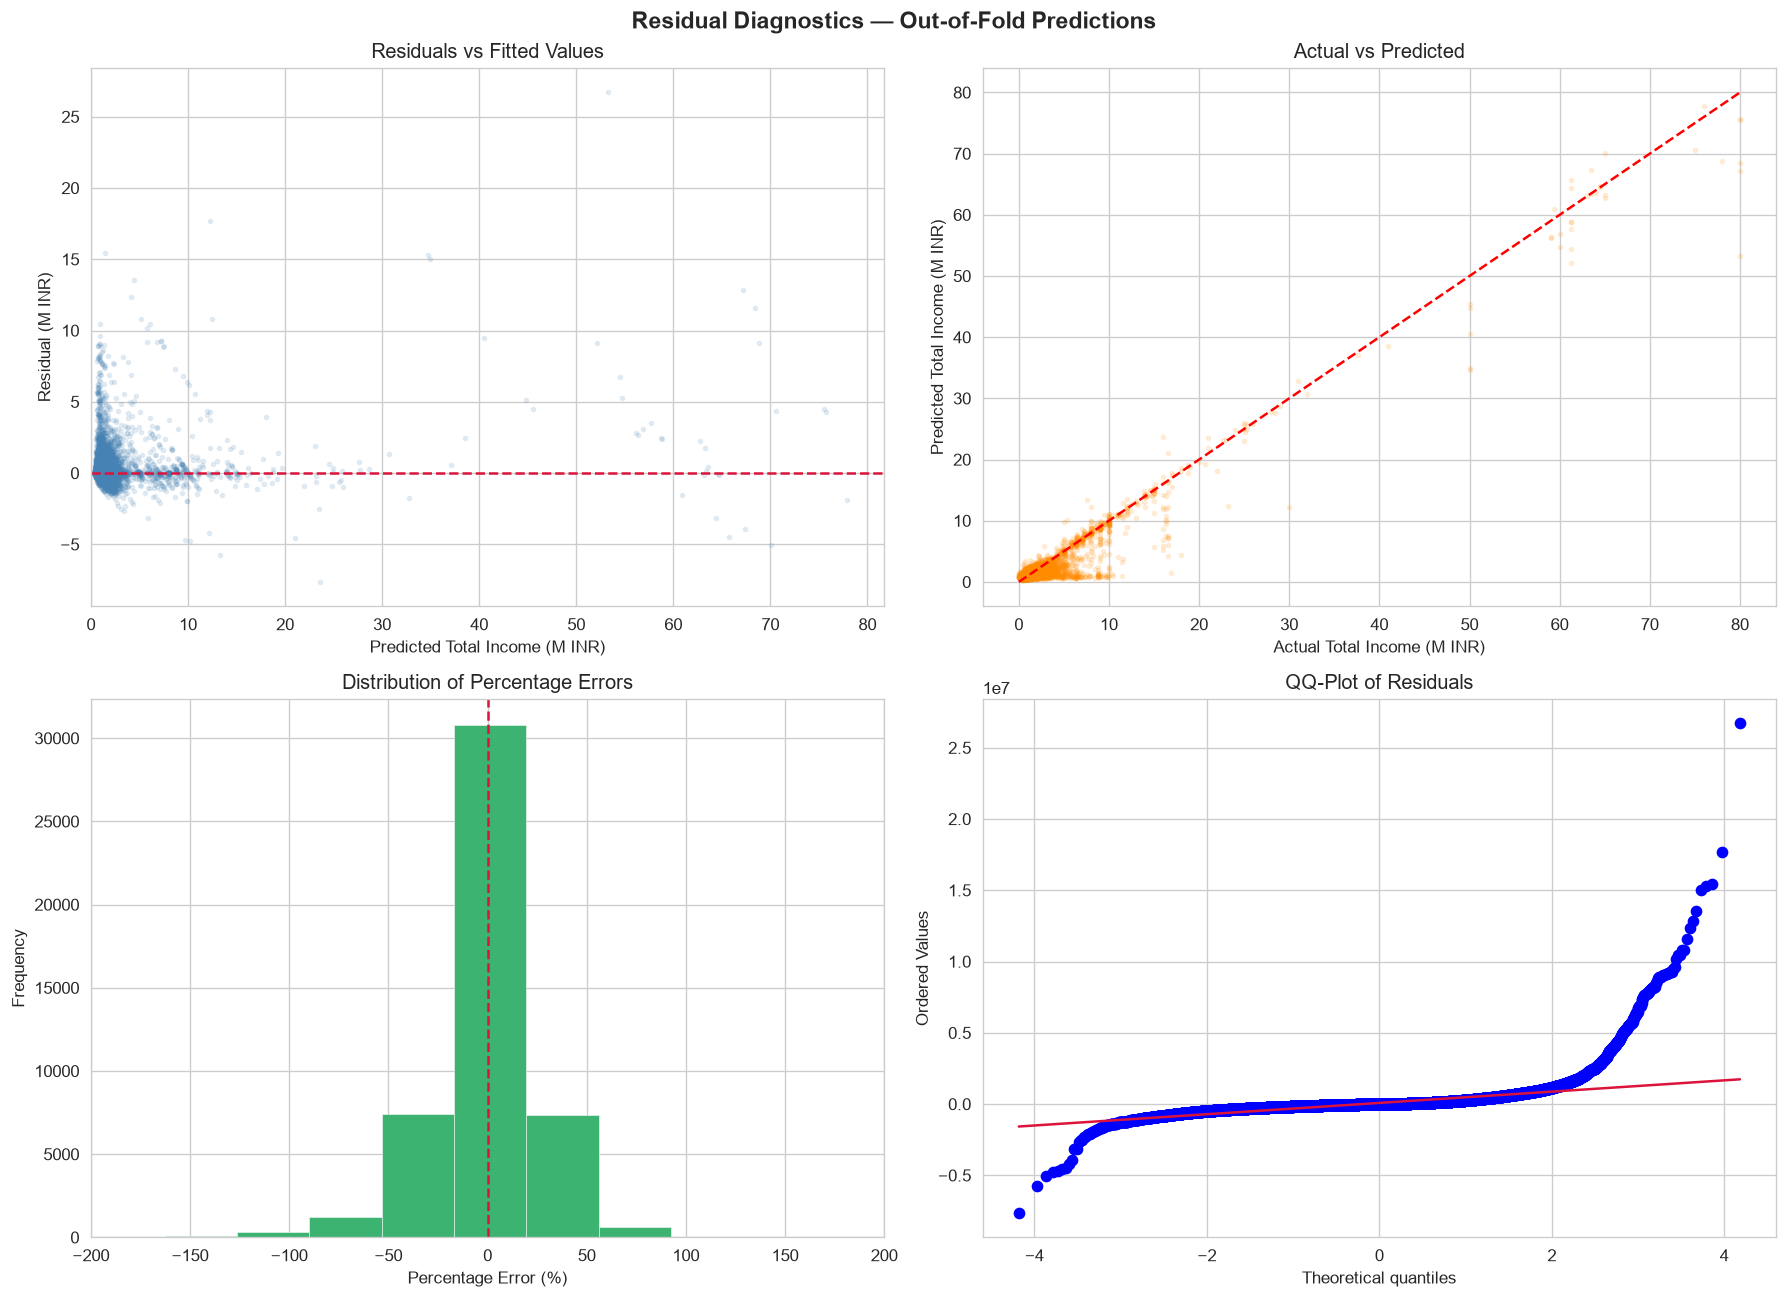

Residual Summary:
  Mean Residual      :        82,908.22 INR
  Median Residual    :          -239.13 INR
  Std of Residuals   :       575,158.95 INR
  Median Abs Pct Err :           11.74%


In [35]:
residuals  = y_total.values - oof_total_pred
pct_errors = residuals / y_total.values * 100

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Residual Diagnostics — Out-of-Fold Predictions', fontsize=14, fontweight='bold')

axes[0, 0].scatter(oof_total_pred / 1e6, residuals / 1e6,
                   alpha=0.12, s=6, color='steelblue')
axes[0, 0].axhline(0, color='crimson', linewidth=1.5, linestyle='--')
axes[0, 0].set_xlabel('Predicted Total Income (M INR)')
axes[0, 0].set_ylabel('Residual (M INR)')
axes[0, 0].set_title('Residuals vs Fitted Values')
axes[0, 0].set_xlim(left=0)

axes[0, 1].scatter(y_total.values / 1e6, oof_total_pred / 1e6,
                   alpha=0.12, s=6, color='darkorange')
lim = max(y_total.max(), oof_total_pred.max()) / 1e6
axes[0, 1].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[0, 1].set_xlabel('Actual Total Income (M INR)')
axes[0, 1].set_ylabel('Predicted Total Income (M INR)')
axes[0, 1].set_title('Actual vs Predicted')

axes[1, 0].hist(pct_errors, bins=100, color='mediumseagreen',
                edgecolor='white', linewidth=0.3)
axes[1, 0].axvline(0, color='crimson', linewidth=1.5, linestyle='--')
axes[1, 0].set_xlabel('Percentage Error (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Percentage Errors')
axes[1, 0].set_xlim(-200, 200)

stats.probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('QQ-Plot of Residuals')
axes[1, 1].get_lines()[1].set_color('crimson')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'residual_diagnostics.png'), bbox_inches='tight')
plt.show()

print(f'Residual Summary:')
print(f'  Mean Residual      : {residuals.mean():>16,.2f} INR')
print(f'  Median Residual    : {np.median(residuals):>16,.2f} INR')
print(f'  Std of Residuals   : {residuals.std():>16,.2f} INR')
print(f'  Median Abs Pct Err : {np.median(np.abs(pct_errors)):>15.2f}%')

### 10.3 Performance by Income Decile

Breaking down model performance by income decile reveals whether the model is systematically weaker for extreme income values. A well-calibrated model should exhibit roughly uniform error rates across deciles.

Model Performance by Income Decile (OOF)
income_decile  count  actual_mean  predicted_mean          mae  median_abs_pct_err   bias_pct
           D1   6024 5.349602e+05    6.709566e+05 1.434556e+05           18.323851  25.421782
           D2   5615 6.722935e+05    7.549961e+05 1.073619e+05            9.597581  12.301556
           D3   2755 7.386130e+05    8.018716e+05 9.964852e+04            8.037431   8.564516
           D4   4913 8.009005e+05    8.586372e+05 1.063749e+05            8.397292   7.208971
           D5   5383 8.972086e+05    9.348423e+05 1.235033e+05            9.593652   4.194534
           D6   4099 9.962259e+05    9.992056e+05 1.245712e+05            8.528663   0.299098
           D7   5741 1.136437e+06    1.101008e+06 1.514775e+05            9.479832  -3.117580
           D8   4060 1.316462e+06    1.203554e+06 2.146162e+05           11.961536  -8.576586
           D9   5094 1.588925e+06    1.338351e+06 3.229051e+05           17.066430 -15.770029
          D10   428

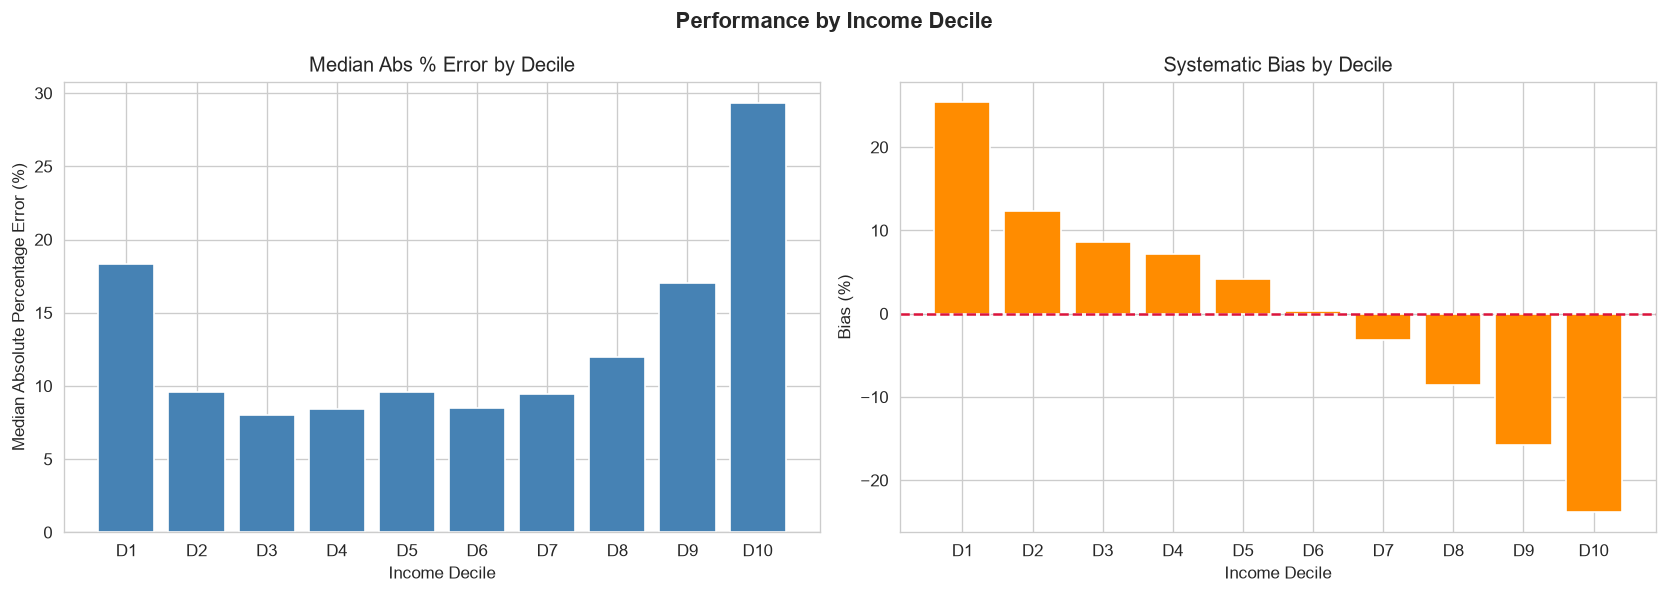

In [36]:
eval_df = pd.DataFrame({
    'actual'       : y_total.values,
    'predicted'    : oof_total_pred,
    'residual'     : residuals,
    'abs_pct_err'  : np.abs(pct_errors),
})
eval_df['income_decile'] = pd.qcut(eval_df['actual'], q=10,
                                    labels=[f'D{i}' for i in range(1, 11)])

decile_summary = eval_df.groupby('income_decile', observed=True).agg(
    count=('actual', 'count'),
    actual_mean=('actual', 'mean'),
    predicted_mean=('predicted', 'mean'),
    mae=('residual', lambda x: np.abs(x).mean()),
    median_abs_pct_err=('abs_pct_err', 'median'),
).reset_index()
decile_summary['bias_pct'] = (
    (decile_summary['predicted_mean'] - decile_summary['actual_mean'])
    / decile_summary['actual_mean'] * 100
)

print('Model Performance by Income Decile (OOF)')
print(decile_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Performance by Income Decile', fontsize=13, fontweight='bold')

axes[0].bar(decile_summary['income_decile'].astype(str),
            decile_summary['median_abs_pct_err'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Income Decile')
axes[0].set_ylabel('Median Absolute Percentage Error (%)')
axes[0].set_title('Median Abs % Error by Decile')

axes[1].bar(decile_summary['income_decile'].astype(str),
            decile_summary['bias_pct'], color='darkorange', edgecolor='white')
axes[1].axhline(0, color='crimson', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Income Decile')
axes[1].set_ylabel('Bias (%)')
axes[1].set_title('Systematic Bias by Decile')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'performance_by_decile.png'), bbox_inches='tight')
plt.show()

---

## 11. Feature Importance Analysis

LightGBM provides two built-in feature importance measures:

1. **Split-based importance**: Number of times a feature is used as a split point across all trees. Can be biased toward high-cardinality categorical features.
2. **Gain-based importance**: Total information gain (reduction in loss) attributable to a feature. This is the more reliable measure and should be the primary reference.

Both measures are computed and visualized. A high ranking on gain-based importance with moderate split-based importance indicates a feature that provides substantial predictive value in a focused set of decision nodes.

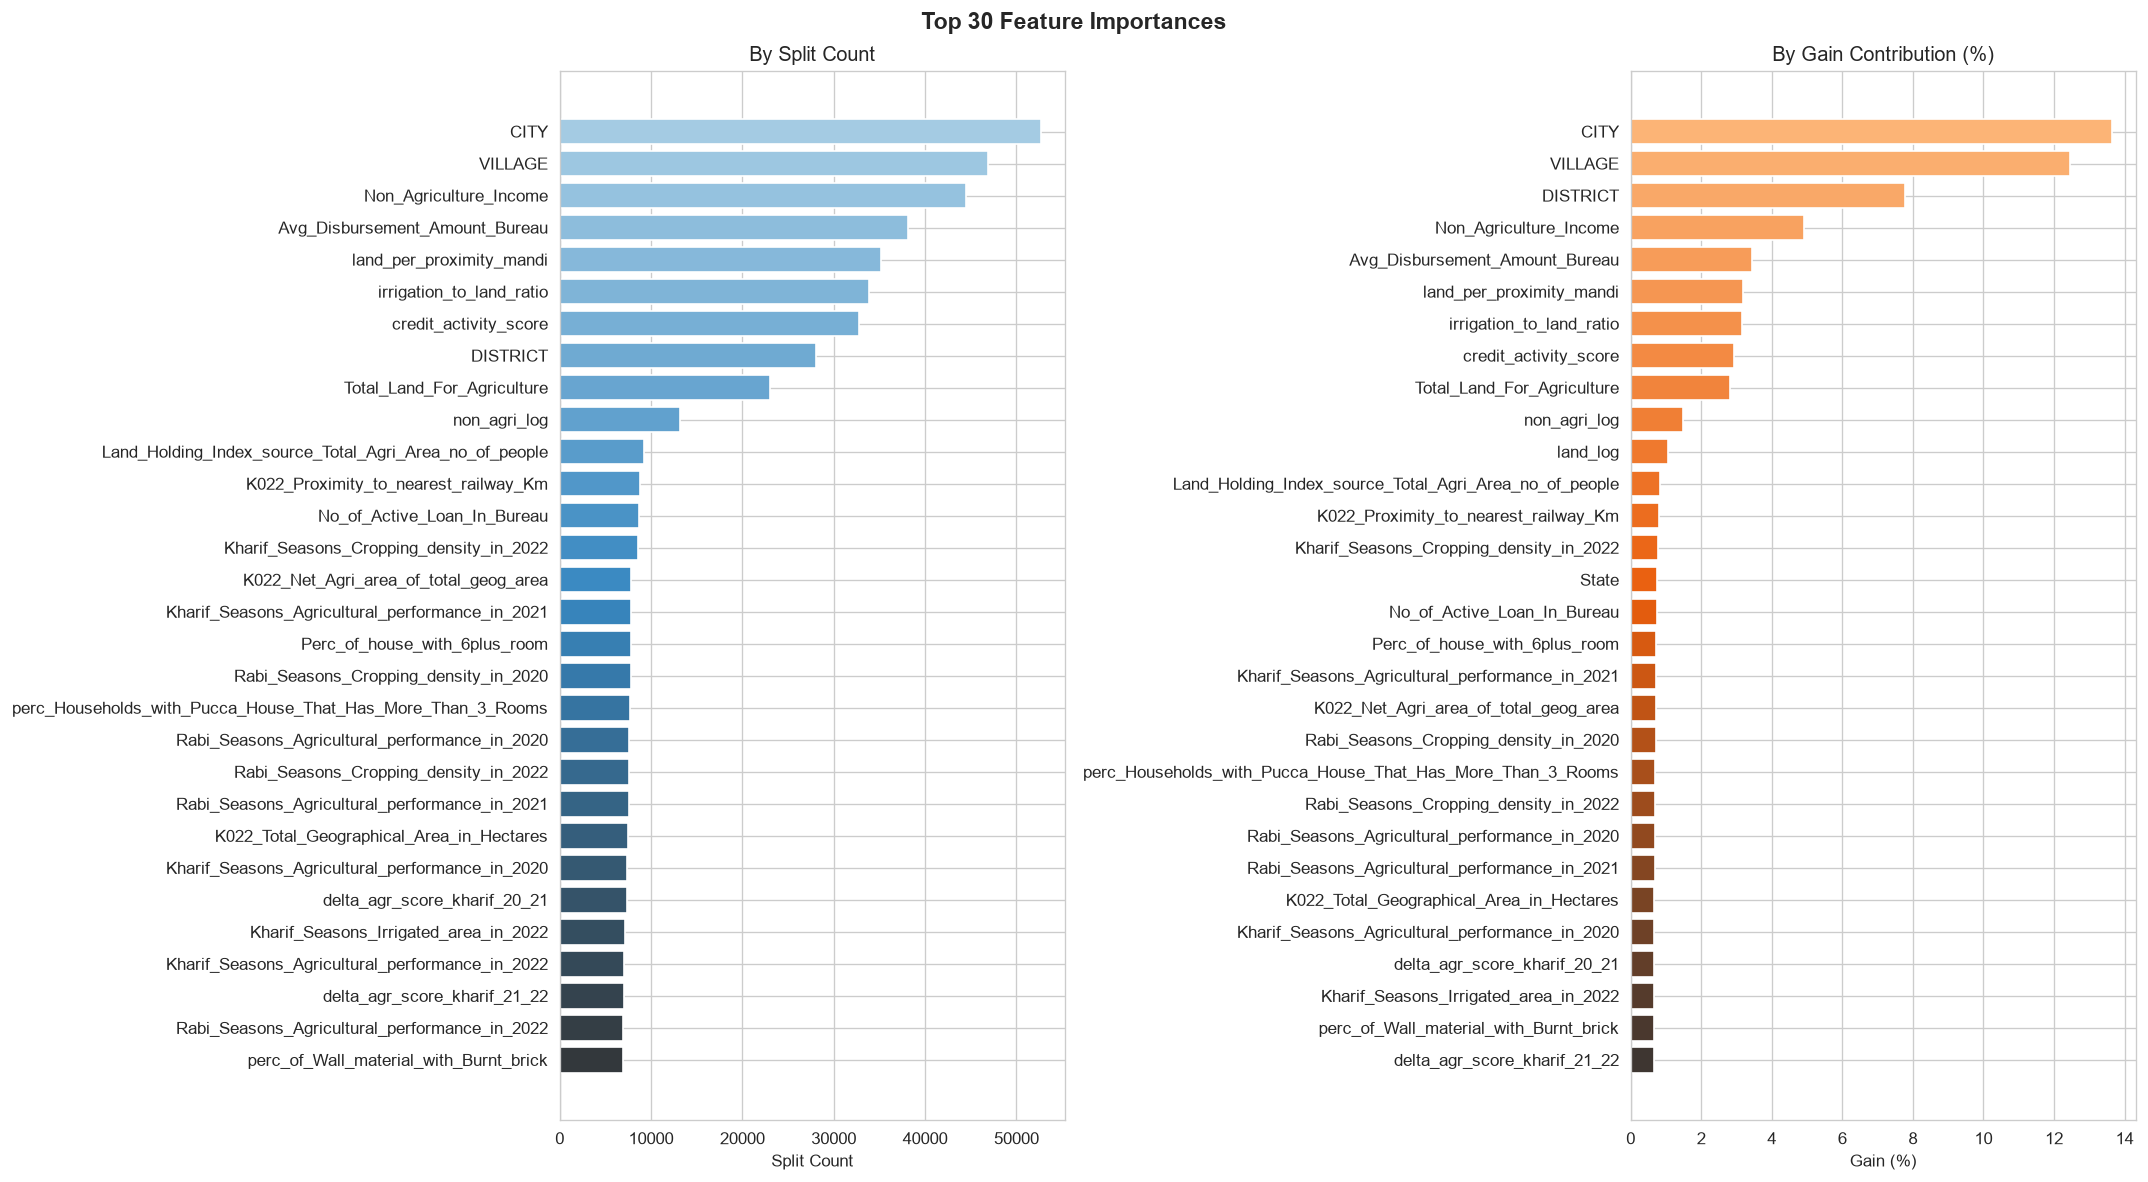

Top 20 Features by Gain:
                                               feature  gain_pct
                                                  CITY 13.640277
                                               VILLAGE 12.444803
                                              DISTRICT  7.778553
                                Non_Agriculture_Income  4.906655
                        Avg_Disbursement_Amount_Bureau  3.449938
                              land_per_proximity_mandi  3.171372
                              irrigation_to_land_ratio  3.161131
                                 credit_activity_score  2.938455
                            Total_Land_For_Agriculture  2.818853
                                          non_agri_log  1.489071
                                              land_log  1.054070
Land_Holding_Index_source_Total_Agri_Area_no_of_people  0.827460
                  K022_Proximity_to_nearest_railway_Km  0.792080
               Kharif_Seasons_Cropping_density_in_2022  0.781016


In [37]:
feat_names = X_train.columns.tolist()
imp_split  = final_model.feature_importances_
imp_gain   = final_model.booster_.feature_importance(importance_type='gain')

importance_df = pd.DataFrame({
    'feature'          : feat_names,
    'importance_split' : imp_split,
    'importance_gain'  : imp_gain,
})
importance_df['gain_pct'] = importance_df['importance_gain'] / importance_df['importance_gain'].sum() * 100

TOP_N = 30
top_gain  = importance_df.nlargest(TOP_N, 'importance_gain')
top_split = importance_df.nlargest(TOP_N, 'importance_split')

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle(f'Top {TOP_N} Feature Importances', fontsize=14, fontweight='bold')

axes[0].barh(top_split['feature'], top_split['importance_split'],
             color=sns.color_palette('Blues_d', TOP_N))
axes[0].set_title('By Split Count')
axes[0].set_xlabel('Split Count')
axes[0].invert_yaxis()

axes[1].barh(top_gain['feature'], top_gain['gain_pct'],
             color=sns.color_palette('Oranges_d', TOP_N))
axes[1].set_title('By Gain Contribution (%)')
axes[1].set_xlabel('Gain (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'feature_importance.png'), bbox_inches='tight')
plt.show()

print('Top 20 Features by Gain:')
print(importance_df.nlargest(20, 'importance_gain')[['feature', 'gain_pct']].to_string(index=False))

---

## 12. Test Set Inference

Final predictions on the test set are generated using the final model trained on all training data.

The inference pipeline follows these steps:
1. Predict `log1p(Agri_Income)` using the final LightGBM model on `X_test`
2. Recover agricultural income: `Agri_Income = expm1(prediction)`
3. Apply non-negativity constraint: `Agri_Income = max(0, Agri_Income)`
4. Reconstruct total income: `Total_Income = Non_Agriculture_Income + Agri_Income`

A distribution sanity check is performed to verify that the test prediction distribution closely mirrors the training distribution, confirming absence of distribution shift or inference bugs.

In [38]:
test_agri_log  = final_model.predict(X_test)
test_agri_pred = np.maximum(np.expm1(test_agri_log), 0)
test_total_pred = test_df['Non_Agriculture_Income'].values + test_agri_pred
test_total_pred = np.maximum(test_total_pred, 0)

print('Test Prediction Statistics:')
print(f'  Count   : {len(test_total_pred):,}')
print(f'  Mean    : {test_total_pred.mean():>16,.2f} INR')
print(f'  Median  : {np.median(test_total_pred):>16,.2f} INR')
print(f'  Min     : {test_total_pred.min():>16,.2f} INR')
print(f'  Max     : {test_total_pred.max():>16,.2f} INR')
print(f'  Std Dev : {test_total_pred.std():>16,.2f} INR')
print()
print('Training Actual Statistics (reference):')
print(f'  Mean    : {y_total.mean():>16,.2f} INR')
print(f'  Median  : {y_total.median():>16,.2f} INR')

Test Prediction Statistics:
  Count   : 9,986
  Mean    :     1,103,773.61 INR
  Median  :       933,802.11 INR
  Min     :       361,884.07 INR
  Max     :    49,655,477.97 INR
  Std Dev :     1,105,263.23 INR

Training Actual Statistics (reference):
  Mean    :     1,222,255.35 INR
  Median  :       950,000.00 INR


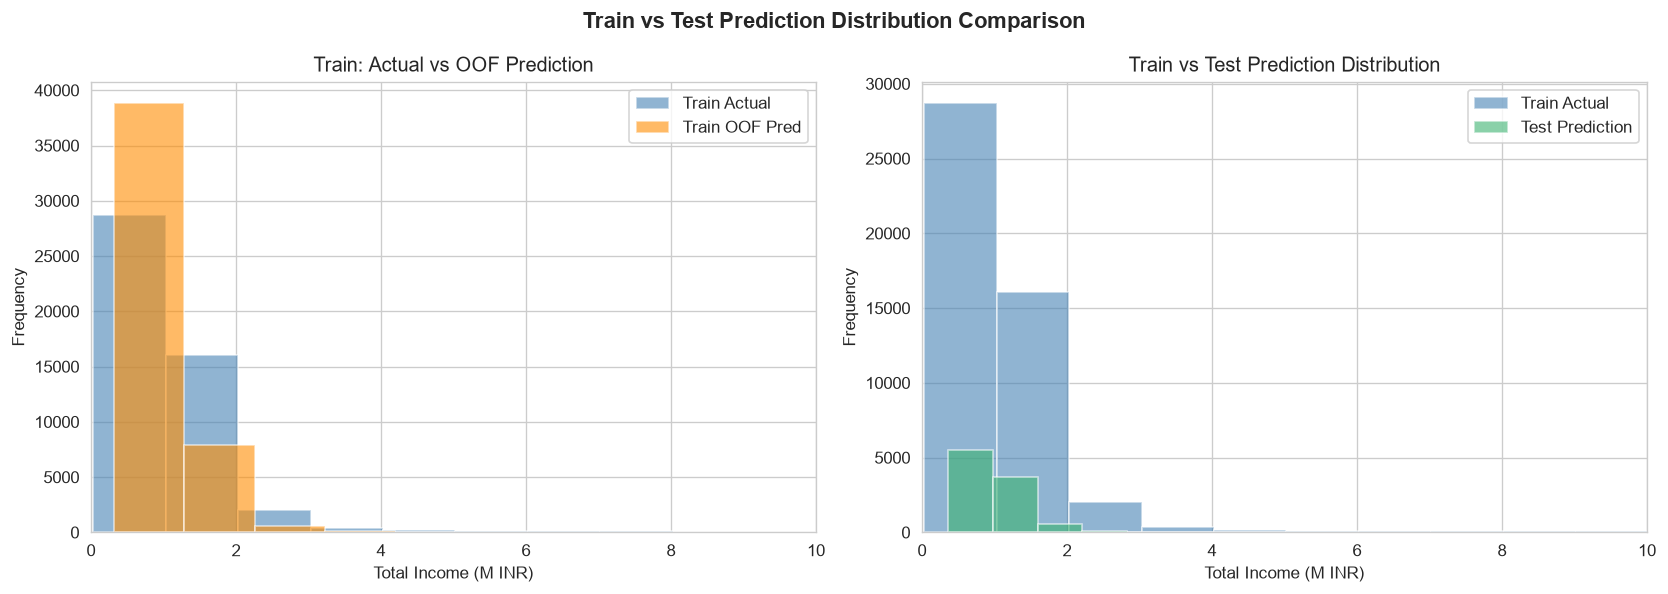

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Train vs Test Prediction Distribution Comparison', fontsize=13, fontweight='bold')

axes[0].hist(y_total / 1e6, bins=80, alpha=0.6, label='Train Actual', color='steelblue')
axes[0].hist(oof_total_pred / 1e6, bins=80, alpha=0.6, label='Train OOF Pred', color='darkorange')
axes[0].set_xlabel('Total Income (M INR)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Train: Actual vs OOF Prediction')
axes[0].legend()
axes[0].set_xlim(0, 10)

axes[1].hist(y_total / 1e6, bins=80, alpha=0.6, label='Train Actual', color='steelblue')
axes[1].hist(test_total_pred / 1e6, bins=80, alpha=0.6, label='Test Prediction', color='mediumseagreen')
axes[1].set_xlabel('Total Income (M INR)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Train vs Test Prediction Distribution')
axes[1].legend()
axes[1].set_xlim(0, 10)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'train_test_distribution.png'), bbox_inches='tight')
plt.show()

In [40]:
test_raw = pd.read_csv(os.path.join(DATASET_DIR, 'lte_test.csv'), usecols=['FarmerID'], low_memory=False)
submission_df = test_raw.copy()
submission_df[TARGET] = test_total_pred.astype(int)

submission_path = os.path.join(ARTIFACT_DIR, 'submission.csv')
submission_df.to_csv(submission_path, index=False)

print(f'Submission saved to: {submission_path}')
print(f'\nSample submission (first 10 rows):')
print(submission_df.head(10).to_string(index=False))

Submission saved to: C:\\Users\\admin\\Documents\\Portofolio\\Farmer Income Prediction\Model\artifacts\submission.csv

Sample submission (first 10 rows):
        FarmerID  Target_Variable_Total_Income
 576972022499073                       1262664
 979235081831136                        783439
 176490610549774                        742654
 977021407171384                       1297036
1334154133262320                       1238435
 232978933363017                        829280
1151623140705580                       1307201
1145445587728930                       1308766
 838736592512939                       1324567
 512185024289381                       1315760


---

## 13. Model Artifact Persistence

All model artifacts are saved to `Model/artifacts/` for reproducibility, deployment, and future analysis.

| Artifact | File | Description |
|---|---|---|
| Final model (joblib) | `final_lgbm_model.pkl` | Scikit-learn API serialized model |
| Final model (native) | `final_lgbm_model.txt` | LightGBM booster text format |
| Label encoders | `label_encoders.pkl` | Dictionary of per-column LabelEncoder objects |
| Training medians | `train_medians.pkl` | Imputation reference values |
| Feature importances | `feature_importance.csv` | Ranked feature importance table |
| CV metrics | `cv_metrics.json` | Per-fold and aggregate cross-validation results |
| Model config | `model_config.json` | Hyperparameters, feature list, and metadata |
| Submission | `submission.csv` | Final test set predictions |
| Visualizations | `*.png` | All generated diagnostic plots |

In [41]:
joblib.dump(final_model, os.path.join(ARTIFACT_DIR, 'final_lgbm_model.pkl'))

final_model.booster_.save_model(os.path.join(ARTIFACT_DIR, 'final_lgbm_model.txt'))

joblib.dump(label_encoders, os.path.join(ARTIFACT_DIR, 'label_encoders.pkl'))

joblib.dump(train_medians, os.path.join(ARTIFACT_DIR, 'train_medians.pkl'))

importance_df.sort_values('importance_gain', ascending=False).to_csv(
    os.path.join(ARTIFACT_DIR, 'feature_importance.csv'), index=False
)

cv_results = {
    'baseline': {
        'fold_metrics': fold_metrics_baseline,
        'mean_MAE'    : float(b_mae),
        'mean_RMSLE'  : float(b_rmsle),
        'mean_WAPE'   : float(b_wape),
        'mean_R2'     : float(b_r2),
    },
    'tuned': {
        'fold_metrics': fold_metrics_tuned,
        'mean_MAE'    : float(t_mae),
        'mean_RMSLE'  : float(t_rmsle),
        'mean_WAPE'   : float(t_wape),
        'mean_R2'     : float(t_r2),
    },
    'oof_metrics': oof_metrics,
}
with open(os.path.join(ARTIFACT_DIR, 'cv_metrics.json'), 'w') as f:
    json.dump(cv_results, f, indent=2, default=str)

model_config = {
    'model_type'               : 'LightGBM',
    'target_variable'          : TARGET,
    'modeling_strategy'        : 'Residual: predict log1p(Agri_Income), reconstruct Total_Income',
    'target_transform'         : 'log1p(Agri_Income)',
    'n_train_samples'          : int(len(X_train)),
    'n_test_samples'           : int(len(X_test)),
    'n_features'               : int(X_train.shape[1]),
    'n_folds'                  : N_FOLDS,
    'optimal_n_estimators'     : optimal_n_estimators,
    'hyperparameters'          : FINAL_PARAMS,
    'cv_baseline_mae'          : float(b_mae),
    'cv_baseline_rmsle'        : float(b_rmsle),
    'cv_baseline_wape'         : float(b_wape),
    'cv_tuned_mae'             : float(t_mae),
    'cv_tuned_rmsle'           : float(t_rmsle),
    'cv_tuned_wape'            : float(t_wape),
    'cv_tuned_r2'              : float(t_r2),
    'oof_mae'                  : float(oof_metrics['MAE']),
    'oof_rmsle'                : float(oof_metrics['RMSLE']),
    'oof_wape'                 : float(oof_metrics['WAPE']),
    'oof_r2'                   : float(oof_metrics['R2']),
    'training_date'            : datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'feature_list'             : feat_names,
    'categorical_features'     : cat_cols_raw,
    'dropped_columns'          : DROP_COLS,
    'temperature_cols_parsed'  : TEMP_COLS,
}
with open(os.path.join(ARTIFACT_DIR, 'model_config.json'), 'w') as f:
    json.dump(model_config, f, indent=2, default=str)

print('All artifacts saved successfully.')
print(f'\nArtifact directory contents:')
for fname in sorted(os.listdir(ARTIFACT_DIR)):
    fpath = os.path.join(ARTIFACT_DIR, fname)
    fsize = os.path.getsize(fpath)
    print(f'  {fname:<48} {fsize/1024:>8.1f} KB')

All artifacts saved successfully.

Artifact directory contents:
  correlation_heatmap.png                             273.4 KB
  cv_metrics.json                                       2.7 KB
  feature_importance.csv                               10.2 KB
  feature_importance.png                              171.3 KB
  final_lgbm_model.pkl                             107362.7 KB
  final_lgbm_model.txt                             107335.3 KB
  income_decomposition.png                            110.1 KB
  label_encoders.pkl                                  122.2 KB
  missing_values.png                                   62.9 KB
  model_config.json                                     8.7 KB
  performance_by_decile.png                            41.5 KB
  residual_diagnostics.png                            149.1 KB
  submission.csv                                      241.4 KB
  target_distribution.png                             114.3 KB
  train_medians.pkl                                   

---

## 14. Summary and Conclusions

This notebook implemented a complete, production-grade LightGBM regression pipeline for predicting total farmer income from a multi-modal tabular dataset of Indian agricultural households.

### Key Design Decisions

| Decision | Rationale |
|---|---|
| Residual modeling strategy | `Non_Agriculture_Income` (r=0.935 with target) is known at inference time; modeling only the agricultural residual reduces variance by 87% |
| log1p target transform | Income is extreme right-skewed (skewness=23.12). Log transform normalizes the gradient signal and is equivalent to minimizing RMSLE |
| L1 (MAE) objective | More robust to income outliers (max 80M INR) compared to L2 (MSE), which over-penalizes extreme values |
| LightGBM native categorical encoding | Handles 5,650-level village cardinality without one-hot explosion; split partitioning is optimal for high-cardinality categoricals |
| 5-fold CV with quantile stratification | Ensures each fold is representative of the full income distribution; prevents fold-variance-driven bias |
| Temporal delta features | Year-over-year groundwater and agricultural score changes capture momentum not visible in static snapshot values |
| Median imputation on train, applied to test | Prevents data leakage from test set statistics |

### Further Improvement Directions

1. **Stacking ensemble**: Add CatBoost and XGBoost as base learners; blend via a linear meta-learner trained with cross-validated OOF predictions.
2. **Cross-validated target encoding**: Replace ordinal label encoding for geographic columns (`DISTRICT`, `VILLAGE`) with properly folded mean target encoding to capture regional income signals.
3. **Bayesian hyperparameter optimization (Optuna)**: Systematic search over a wider hyperparameter space using Tree-structured Parzen Estimators.
4. **Spatial cross-validation**: Use `GroupKFold` by `DISTRICT` or `State` to assess how well the model generalizes to entirely new geographic regions.
5. **Outlier treatment**: Winsorize the top 0.1% of agricultural income values during training to reduce gradient contamination from extreme observations.